# JetBot AI 道路辨識 - 模型訓練 (GPU)

使用 **ResNet-18** + **CUDA GPU** 進行迴歸訓練，從 224×224 影像預測轉向座標 (X, Y)。

## 訓練流程
1. 從 `dataset_xy/` 載入影像，並從檔名解析 X, Y 座標
2. 資料增強（水平翻轉 + 色彩擾動 + 正規化）
3. 90/10 訓練/測試分割
4. ResNet-18 最後一層改為 `Linear(512, 2)` 輸出 X, Y
5. Adam + MSE Loss 訓練 70 個 Epochs（GPU 加速）
6. 儲存最佳模型 `best_steering_model_xy.pth`

## 1. 匯入套件 & 確認 GPU

In [31]:
import os
import glob
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
import time

# 設定 matplotlib 支援中文顯示
matplotlib.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

# ========== 強制使用 GPU ==========
assert torch.cuda.is_available(), '錯誤：未偵測到 CUDA GPU！請確認 GPU 驅動已安裝。'
device = torch.device('cuda')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')
print(f'GPU            : {torch.cuda.get_device_name(0)}')
print(f'GPU Memory     : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
print(f'使用裝置       : {device}')

PyTorch version: 2.7.1+cu118
CUDA available : True
GPU            : NVIDIA GeForce GTX 1650
GPU Memory     : 4.0 GB
使用裝置       : cuda


## 2. 定義 XYDataset

In [32]:
class XYDataset(Dataset):
    """
    自定義資料集：從檔名 xy_XXX_YYY_uuid.jpg 解析座標。
    座標值會從 [0, 224] 正規化到 [-1, 1] 的範圍。
    """
    def __init__(self, directory, transform=None, random_hflip=False):
        self.directory = directory
        self.transform = transform
        self.random_hflip = random_hflip
        self.image_paths = sorted(glob.glob(os.path.join(directory, 'xy_*.jpg')))
        print(f'載入 {len(self.image_paths)} 張影像 from {directory}')

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')

        # 從檔名解析座標: xy_XXX_YYY_uuid.jpg
        basename = os.path.basename(image_path)
        parts = basename.split('_')
        x = int(parts[1])
        y = int(parts[2])

        # 正規化到 [-1, 1]（原始範圍約 0~224）
        x = (x - 112.0) / 112.0
        y = (y - 112.0) / 112.0

        # 隨機水平翻轉（同時翻轉 x 座標）
        if self.random_hflip and random.random() > 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)
            x = -x

        if self.transform:
            image = self.transform(image)

        target = torch.tensor([x, y], dtype=torch.float32)
        return image, target

## 3. 資料預處理與分割

In [33]:
DATASET_DIR = 'dataset_xy'
BATCH_SIZE = 16
NUM_EPOCHS = 100        # 增加到 100 個 epoch
LEARNING_RATE = 1e-3
BEST_MODEL_PATH = 'best_steering_model_xy.pth'

# 訓練集 transform（強化資料增強）
train_transform = transforms.Compose([
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# 測試集 transform（不做增強）
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# 建立完整資料集（用於分割）
full_dataset = XYDataset(DATASET_DIR, transform=train_transform, random_hflip=True)

# 90% 訓練, 10% 測試
total = len(full_dataset)
test_size = int(total * 0.1)
train_size = total - test_size

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_indices = train_dataset.indices
test_indices_list = test_dataset.indices

train_subset = Subset(
    XYDataset(DATASET_DIR, transform=train_transform, random_hflip=True),
    train_indices
)
test_subset = Subset(
    XYDataset(DATASET_DIR, transform=test_transform, random_hflip=False),
    test_indices_list
)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'\n訓練集: {len(train_subset)} 張')
print(f'測試集: {len(test_subset)} 張')
print(f'Batch size: {BATCH_SIZE}')
print(f'Epochs: {NUM_EPOCHS}')
print(f'訓練 batches: {len(train_loader)}')


載入 450 張影像 from dataset_xy
載入 450 張影像 from dataset_xy
載入 450 張影像 from dataset_xy

訓練集: 405 張
測試集: 45 張
Batch size: 16
Epochs: 100
訓練 batches: 26


## 4. 視覺化樣本資料

載入 450 張影像 from dataset_xy


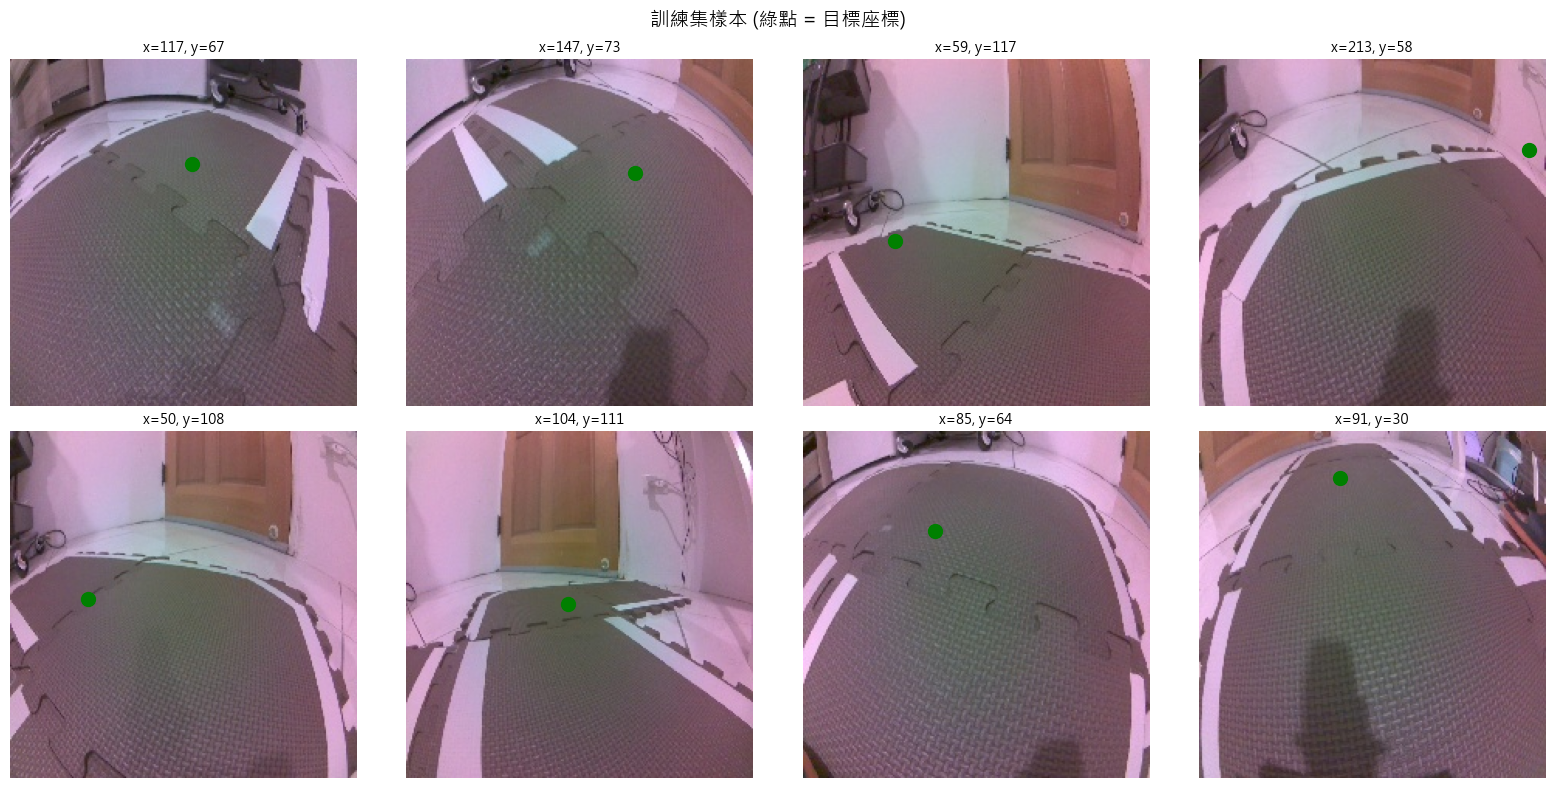

In [34]:
# 顯示幾張訓練樣本
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('訓練集樣本 (綠點 = 目標座標)', fontsize=14)

sample_ds = XYDataset(DATASET_DIR, transform=None, random_hflip=False)
indices = random.sample(range(len(sample_ds)), 8)

for i, idx in enumerate(indices):
    img_pil = Image.open(sample_ds.image_paths[idx]).convert('RGB')
    basename = os.path.basename(sample_ds.image_paths[idx])
    parts = basename.split('_')
    x_raw, y_raw = int(parts[1]), int(parts[2])

    ax = axes[i // 4][i % 4]
    ax.imshow(img_pil)
    ax.plot(x_raw, y_raw, 'go', markersize=10)
    ax.set_title(f'x={x_raw}, y={y_raw}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. 建立模型（GPU）

In [35]:
# 載入預訓練 ResNet-18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 修改最後一層：512 -> 2 (X, Y)
model.fc = nn.Linear(512, 2)

# 搬移到 GPU（強制 CUDA）
model = model.to(device)

# ===== 驗證模型確實在 GPU 上 =====
print(f'使用裝置: {device}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'模型最後一層: {model.fc}')

# 確認模型參數在 GPU 上
param_device = next(model.parameters()).device
print(f'模型參數位於: {param_device}')
assert str(param_device).startswith('cuda'), f'錯誤！模型在 {param_device} 而非 GPU！'
print(f'模型已載入至 GPU ✓')
print(f'GPU 記憶體已使用: {torch.cuda.memory_allocated(0) / 1024**2:.1f} MB')

使用裝置: cuda
GPU: NVIDIA GeForce GTX 1650
模型最後一層: Linear(in_features=512, out_features=2, bias=True)
模型參數位於: cuda:0
模型已載入至 GPU ✓
GPU 記憶體已使用: 154.4 MB


## 6. 定義損失函數與最佳化器

In [36]:
# Adam + weight_decay 正則化防止過擬合
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# 學習率排程器：test loss 停滯時自動降低 LR
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

print(f'Optimizer: Adam (lr={LEARNING_RATE}, weight_decay=1e-4)')
print(f'Scheduler: ReduceLROnPlateau (factor=0.5, patience=10)')
print(f'Loss: MSE Loss')


Optimizer: Adam (lr=0.001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=10)
Loss: MSE Loss


## 7. 訓練迴圈（GPU 加速）

In [37]:
best_loss = float('inf')
train_losses = []
test_losses = []

print(f'開始訓練 {NUM_EPOCHS} 個 Epochs')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print()

total_start = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    # === 訓練階段 ===
    model.train()
    running_loss = 0.0
    for images, targets in train_loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = F.mse_loss(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_subset)
    train_losses.append(train_loss)

    # === 測試階段 ===
    model.eval()
    test_running_loss = 0.0
    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            outputs = model(images)
            loss = F.mse_loss(outputs, targets)
            test_running_loss += loss.item() * images.size(0)

    test_loss = test_running_loss / len(test_subset)
    test_losses.append(test_loss)

    # 學習率排程器
    scheduler.step(test_loss)
    current_lr = optimizer.param_groups[0]['lr']

    epoch_time = time.time() - epoch_start

    # 儲存最佳模型
    if test_loss < best_loss:
        best_loss = test_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        saved_marker = ' >> SAVED'
    else:
        saved_marker = ''

    if (epoch + 1) % 5 == 0 or epoch == 0:
        gpu_mem = torch.cuda.memory_allocated(0) / 1024**2
        print(f'Epoch [{epoch+1:3d}/{NUM_EPOCHS}]  '
              f'Train: {train_loss:.6f}  '
              f'Test: {test_loss:.6f}  '
              f'LR: {current_lr:.1e}  '
              f'Time: {epoch_time:.1f}s  '
              f'GPU: {gpu_mem:.0f}MB{saved_marker}')

total_time = time.time() - total_start
print(f'\nDone! {total_time:.1f}s, Best Test Loss: {best_loss:.6f}')
print(f'Model saved: {BEST_MODEL_PATH}')


開始訓練 100 個 Epochs
GPU: NVIDIA GeForce GTX 1650

Epoch [  1/100]  Train: 0.390833  Test: 0.859700  LR: 1.0e-03  Time: 5.2s  GPU: 245MB >> SAVED
Epoch [  5/100]  Train: 0.048531  Test: 0.056272  LR: 1.0e-03  Time: 4.7s  GPU: 245MB
Epoch [ 10/100]  Train: 0.042736  Test: 0.067942  LR: 1.0e-03  Time: 4.7s  GPU: 245MB
Epoch [ 15/100]  Train: 0.030417  Test: 0.050733  LR: 1.0e-03  Time: 4.7s  GPU: 245MB
Epoch [ 20/100]  Train: 0.038246  Test: 0.037531  LR: 1.0e-03  Time: 4.7s  GPU: 245MB
Epoch [ 25/100]  Train: 0.019464  Test: 0.034810  LR: 1.0e-03  Time: 4.9s  GPU: 245MB
Epoch [ 30/100]  Train: 0.028483  Test: 0.024068  LR: 1.0e-03  Time: 4.7s  GPU: 245MB
Epoch [ 35/100]  Train: 0.027948  Test: 0.060893  LR: 1.0e-03  Time: 4.8s  GPU: 245MB
Epoch [ 40/100]  Train: 0.017766  Test: 0.025980  LR: 5.0e-04  Time: 4.8s  GPU: 245MB
Epoch [ 45/100]  Train: 0.014101  Test: 0.025577  LR: 5.0e-04  Time: 4.8s  GPU: 245MB
Epoch [ 50/100]  Train: 0.013269  Test: 0.027738  LR: 5.0e-04  Time: 4.9s  GPU: 245

## 8. 訓練結果視覺化

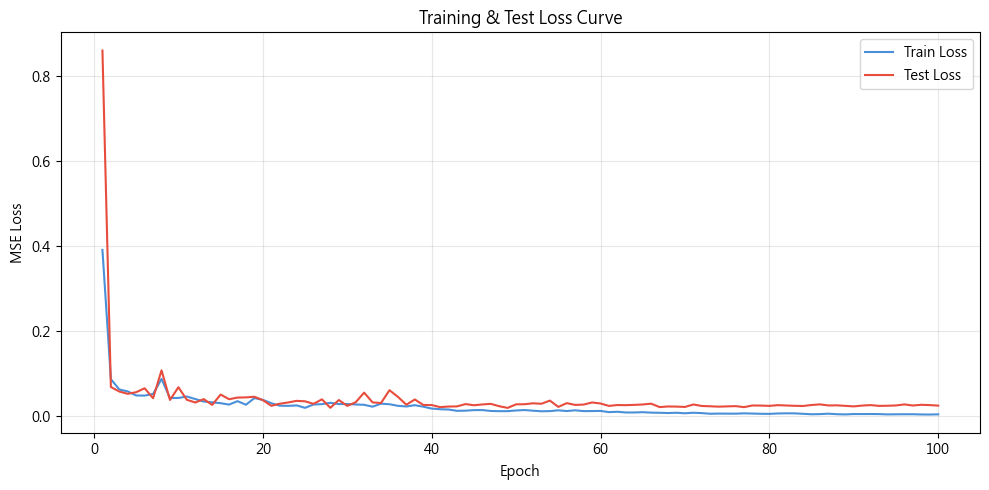

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(range(1, NUM_EPOCHS+1), train_losses, label='Train Loss', color='#4A90D9')
ax.plot(range(1, NUM_EPOCHS+1), test_losses, label='Test Loss', color='#E74C3C')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training & Test Loss Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. 測試集預測結果視覺化

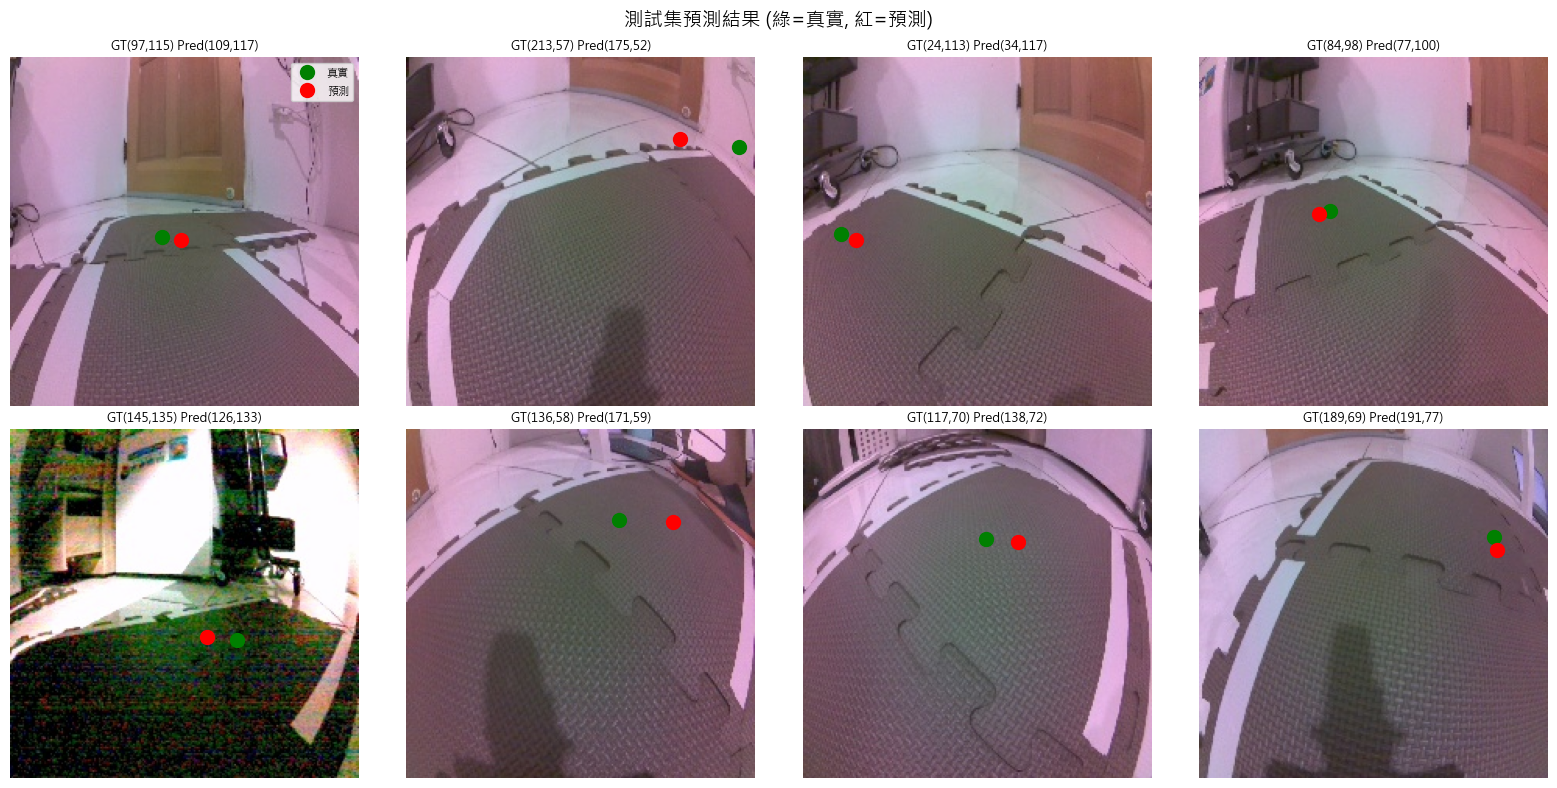


最佳模型路徑: c:\Users\andy8\Desktop\NTUT_Media\Project5\best_steering_model_xy.pth


In [39]:
# 載入最佳模型
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

# 取幾張測試集影像做預測
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('測試集預測結果 (綠=真實, 紅=預測)', fontsize=14)

sample_indices = random.sample(range(len(test_subset)), min(8, len(test_subset)))

for i, si in enumerate(sample_indices):
    img_tensor, target = test_subset[si]
    with torch.no_grad():
        pred = model(img_tensor.unsqueeze(0).to(device)).cpu().squeeze()

    # 反正規化座標到像素
    tx = int(target[0].item() * 112 + 112)
    ty = int(target[1].item() * 112 + 112)
    px = int(pred[0].item() * 112 + 112)
    py = int(pred[1].item() * 112 + 112)

    # 反正規化影像
    img_np = img_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    ax = axes[i // 4][i % 4]
    ax.imshow(img_np)
    ax.plot(tx, ty, 'go', markersize=10, label='真實')
    ax.plot(px, py, 'ro', markersize=10, label='預測')
    ax.set_title(f'GT({tx},{ty}) Pred({px},{py})', fontsize=9)
    ax.axis('off')

axes[0][0].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'\n最佳模型路徑: {os.path.abspath(BEST_MODEL_PATH)}')